#### 1. Set up the reaction graph from DFT data 

In [1]:
from arcs.generate import GraphGenerator

graph = GraphGenerator().from_file(
    filename='../src/arcs/data/dft_data.json',
    temperature=248,
    pressure=20,
    max_reaction_length=5
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:569: RuntimeWarning: overflow encountered in exp
  K = np.exp(-(gibbs_free_energy) / ((Boltzmann / e) * temperature))
/Users/badw/github-projects/arcs/src/arcs/generate.py:610: UserWarning: 8 O2 + 1 S8 = 8 SO2 has K=inf
  warnings.warn(
/Users/badw/github-projects/arcs/src/arcs/generate.py:569: RuntimeWarning: overflow encountered in exp
  K = np.exp(-(gibbs_free_energy) / ((Boltzmann / e) * temperature))
/Users/badw/github-projects/arcs/src/arcs/generate.py:610: UserWarning: 8 H2 + 1 S8 = 8 H2S has K=inf
  warnings.warn(
/Users/badw/github-projects/arcs/src/arcs/generate.py:569: RuntimeWarning: overflow encountered in exp
  K = np.exp(-(gibbs_free_energy) / ((Boltzmann / e) * temperature))
/Users/badw/github-projects/arcs/src/arcs/generate.py:610: UserWarning: 8 O2 + 8 H2O + 1 S8 = 8 H2SO3 has K=inf
  warnings.warn(
/Users/badw/github-projects/arcs/src/arcs/generate.py:569: RuntimeWarning: overflow encountered in exp
  K = np.exp(-

#### 2. Sample the `graph`

In [6]:
from arcs.traversal import Traversal
from arcs.generate import GenerateInitialConcentrations

gic = GenerateInitialConcentrations(graph=graph).update_ic(
    {'H2O':30,'O2':10,'SO2':10,'H2S':0,'NO2':10,"CH4":100}
    )

t = Traversal(graph=graph)

data = t.sample(initial_concentrations=gic,ncpus=4,nsamples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

#### 3. generate reaction statistics

In [7]:
from arcs.analysis import AnalyseSampling
import pandas as pd 

analysis = AnalyseSampling()
stats = pd.Series(analysis.reaction_statistics(data)).sort_values(ascending=False)
stats.head(20)

1 O2 + 1 CH4 = 1 H2CO + 1 H2O               182
1 CH4 + 2 NO2 = 1 CO2 + 2 H2O + 1 N2        160
2 O2 + 1 CH4 = 1 CO2 + 2 H2O                139
1 CH2O2 + 1 H2S = 1 CH4 + 1 SO2             128
1 CH3CHO + 1 H2O = 1 CH2O2 + 1 CH4          104
1 O2 + 1 CH4 = 2 H2 + 1 CO2                  95
1 CO + 3 H2 = 1 CH4 + 1 H2O                  88
1 O2 + 1 CH4 = 1 CH2O2 + 1 H2                87
1 H2 + 1 CH3OH = 1 CH4 + 1 H2O               86
1 CH4 + 2 NO2 = 1 CO2 + 1 NH3 + 1 HNO2       84
2 O2 + 1 CH4 + 1 SO2 = 1 CH2O2 + 1 H2SO4     79
1 CO + 1 H2O + 1 H2S = 1 CH4 + 1 SO2         75
2 H2 + 1 H2CO = 1 CH4 + 1 H2O                71
4 H2 + 1 CO2 = 1 CH4 + 2 H2O                 67
1 H2 + 1 CO2 + 1 H2S = 1 CH4 + 1 SO2         67
4 CO + 2 H2O = 1 CH4 + 3 CO2                 64
1 CO + 1 CH4 + 1 NO2 = 1 CH3COOH + 1 NO      60
1 CH3OH + 1 NO = 1 CH4 + 1 NO2               56
1 CH2O2 + 3 H2 = 1 CH4 + 2 H2O               48
3 O2 + 2 CH4 = 2 CH2O2 + 2 H2O               44
dtype: int64

#### 4. generate mean concentrations and differences

In [8]:
average_data = pd.DataFrame(analysis.average_sampling(data))
average_data = average_data.loc[~(average_data==0).all(axis=1)]
average_data.sort_values(by='diff',inplace=True)
print(average_data.round(2).to_string())

          initial   mean  diff   sem   std    var
CH4         100.0  92.93 -7.07  0.11  5.79  33.49
O2           10.0   4.11 -5.89  0.10  5.16  26.60
NO2          10.0   6.84 -3.16  0.09  4.64  21.55
SO2          10.0   8.23 -1.77  0.07  3.43  11.78
CH3OH         0.0   0.00  0.00  0.00  0.00   0.00
CH3CHO        0.0   0.00  0.00  0.00  0.00   0.00
S8            0.0   0.04  0.04  0.00  0.20   0.04
CH3COOH       0.0   0.13  0.13  0.02  1.01   1.02
HNO3          0.0   0.18  0.18  0.02  1.01   1.02
CO            0.0   0.23  0.23  0.03  1.33   1.77
CH3CH2OH      0.0   0.25  0.25  0.03  1.71   2.92
H2S           0.0   0.26  0.26  0.01  0.73   0.53
NH3           0.0   0.41  0.41  0.03  1.38   1.90
NO            0.0   0.43  0.43  0.04  1.97   3.90
H2SO3         0.0   0.43  0.43  0.04  1.83   3.36
H2SO4         0.0   0.51  0.51  0.03  1.80   3.24
HNO2          0.0   0.52  0.52  0.03  1.57   2.47
N2            0.0   0.81  0.81  0.04  1.84   3.38
H2CO          0.0   1.33  1.33  0.06  3.28  10.79


#### 5. Plot 

/var/folders/40/xmstzxyn7377k__pn0yxn6w80000gn/T/ipykernel_96073/949321809.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(name='RdBu')  # or any other colormap


<Axes: >

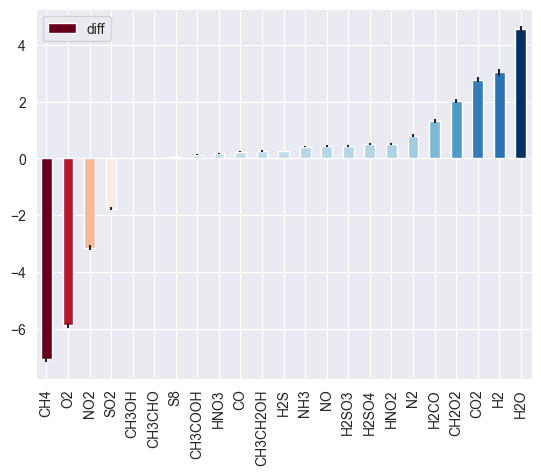

In [9]:
import seaborn as sns 
from matplotlib.cm import get_cmap
import matplotlib.colors as colors
sns.set_style('darkgrid')
sns.set_palette('pastel')


norm = colors.Normalize(
    vmin=average_data['diff'].min(), vmax=average_data['diff'].max()
    )
cmap = get_cmap(name='RdBu')  # or any other colormap

bar_colors = [cmap(norm(value)) for value in average_data['diff']]

average_data.plot.bar(y='diff',yerr='sem',color=bar_colors)

#### 5. generate a `pyvis` graph 

In [18]:
pyvis_kwargs = {'width':'50%','notebook':False,"font_color":'white','directed':True}
g = analysis.result_to_pyvis(data,head=10,**pyvis_kwargs)
g.save_graph(name="example_pyvis_graph.html")

In [121]:
! open example_pyvis_graph.html